In [6]:
!unzip /content/sample_data/playground-series-s6e2.zip

Archive:  /content/sample_data/playground-series-s6e2.zip
  inflating: sample_submission.csv   
  inflating: test.csv                
  inflating: train.csv               


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_csv('train.csv')

In [8]:
df.head()

,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [9]:
df = df.drop('id', axis=1)
display(df.head())

,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,58,1,4,152,239,0,0,158,1,3.6,2,2,7,Presence
1,52,1,1,125,325,0,2,171,0,0.0,1,0,3,Absence
2,56,0,2,160,188,0,2,151,0,0.0,1,0,3,Absence
3,44,0,3,134,229,0,2,150,0,1.0,2,0,3,Absence
4,58,1,4,140,234,0,2,125,1,3.8,2,3,3,Presence


In [11]:
df.isnull().sum()

,0
Age,0
Sex,0
Chest pain type,0
BP,0
Cholesterol,0
FBS over 120,0
EKG results,0
Max HR,0
Exercise angina,0
ST depression,0


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   Age                      630000 non-null  int64  
 1   Sex                      630000 non-null  int64  
 2   Chest pain type          630000 non-null  int64  
 3   BP                       630000 non-null  int64  
 4   Cholesterol              630000 non-null  int64  
 5   FBS over 120             630000 non-null  int64  
 6   EKG results              630000 non-null  int64  
 7   Max HR                   630000 non-null  int64  
 8   Exercise angina          630000 non-null  int64  
 9   ST depression            630000 non-null  float64
 10  Slope of ST              630000 non-null  int64  
 11  Number of vessels fluro  630000 non-null  int64  
 12  Thallium                 630000 non-null  int64  
 13  Heart Disease            630000 non-null  object 
dtypes: f

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,630000.0,54.136706,8.256301,29.0,48.0,54.0,60.0,77.0
Sex,630000.0,0.714735,0.451541,0.0,0.0,1.0,1.0,1.0
Chest pain type,630000.0,3.312752,0.851615,1.0,3.0,4.0,4.0,4.0
BP,630000.0,130.497433,14.975802,94.0,120.0,130.0,140.0,200.0
Cholesterol,630000.0,245.011814,33.681581,126.0,223.0,243.0,269.0,564.0
FBS over 120,630000.0,0.079987,0.271274,0.0,0.0,0.0,0.0,1.0
EKG results,630000.0,0.981660,0.998783,0.0,0.0,0.0,2.0,2.0
Max HR,630000.0,152.816763,19.112927,71.0,142.0,157.0,166.0,202.0
Exercise angina,630000.0,0.273725,0.445870,0.0,0.0,0.0,1.0,1.0
ST depression,630000.0,0.716028,0.948472,0.0,0.0,0.1,1.4,6.2


In [16]:
df['Heart Disease'] = df['Heart Disease'].map({'Presence': 1, 'Absence': 0})
display(df['Heart Disease'].value_counts())

,count
Heart Disease,
0,347546
1,282454


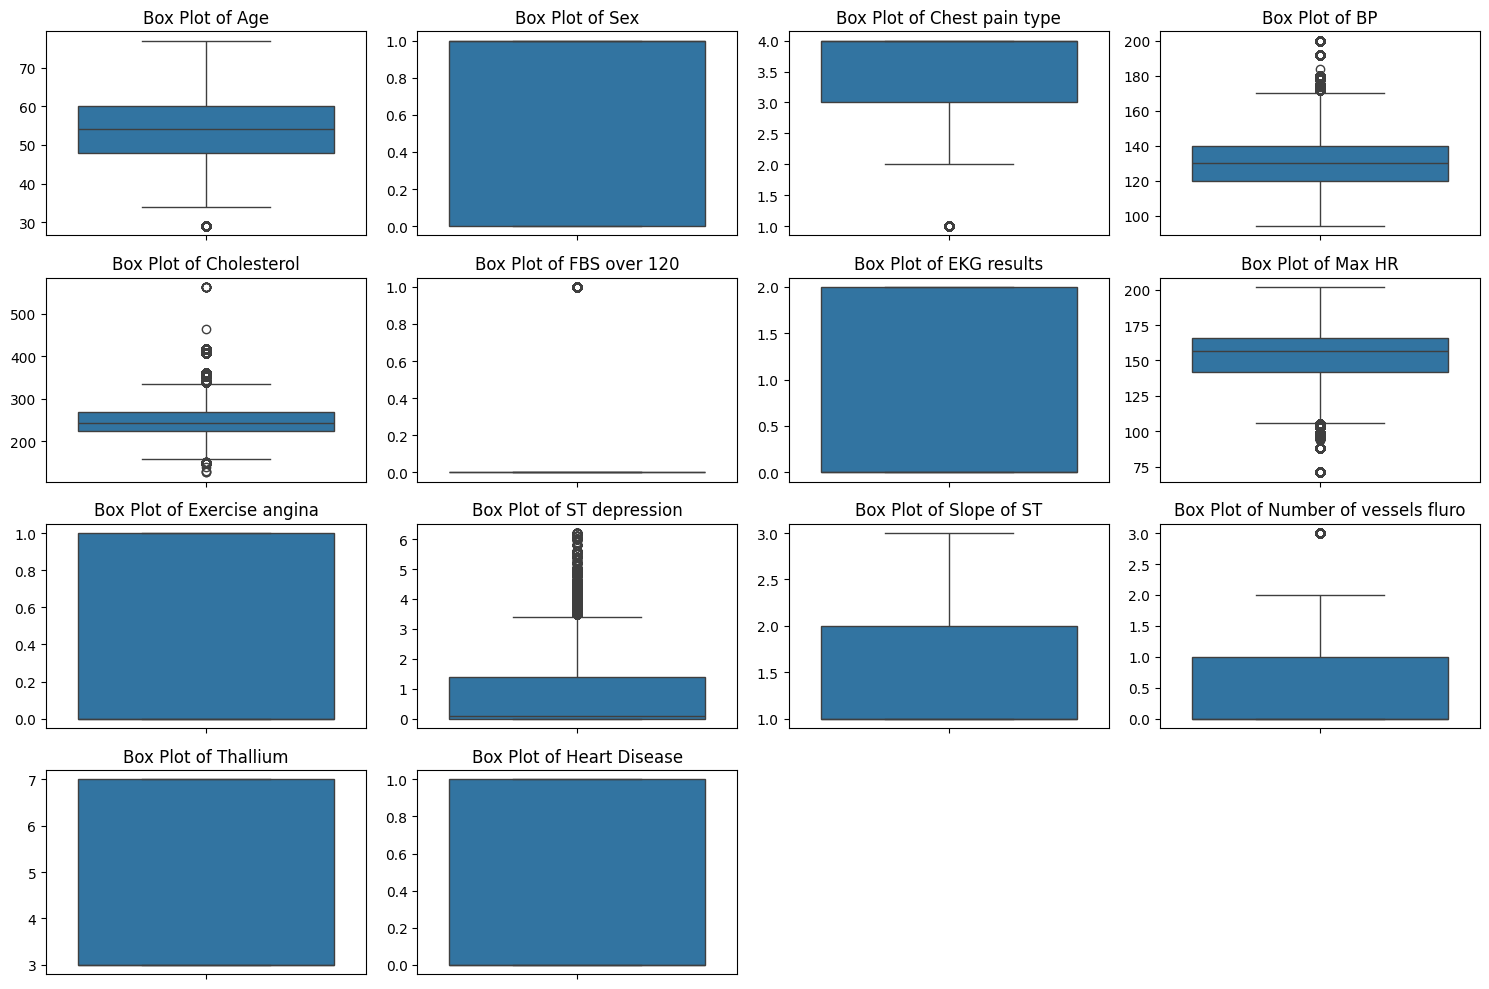

In [17]:
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i + 1) # Adjust subplot grid as needed
    sns.boxplot(y=df[col])
    plt.title(f'Box Plot of {col}')
    plt.ylabel('')
plt.tight_layout()
plt.show()

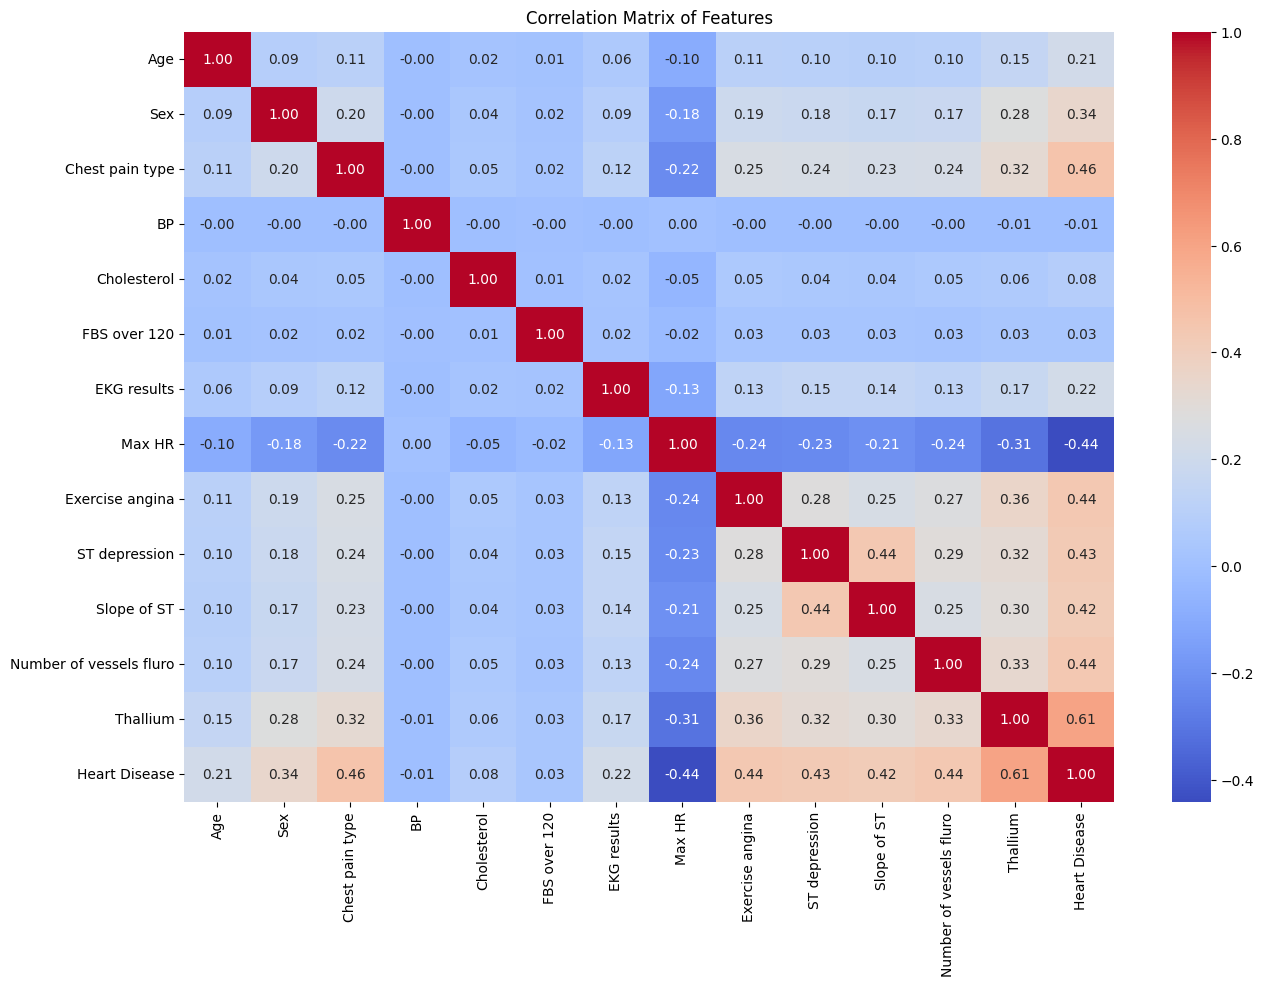

In [18]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Features')
plt.show()

Heart Disease
0    347546
1    282454
Name: count, dtype: int64


/tmp/ipykernel_5491/2043268606.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=heart_disease_counts.index, y=heart_disease_counts.values, palette='viridis')


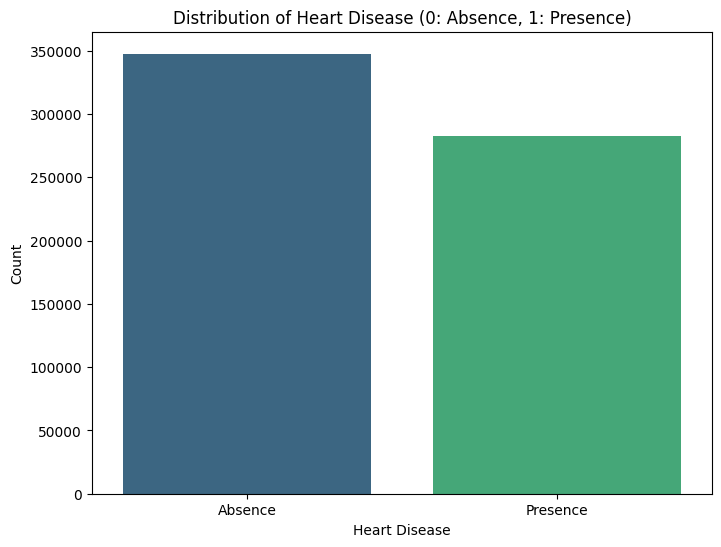

In [19]:
heart_disease_counts = df['Heart Disease'].value_counts()
print(heart_disease_counts)

plt.figure(figsize=(8, 6))
sns.barplot(x=heart_disease_counts.index, y=heart_disease_counts.values, palette='viridis')
plt.title('Distribution of Heart Disease (0: Absence, 1: Presence)')
plt.xlabel('Heart Disease')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1], labels=['Absence', 'Presence'])
plt.show()

In [20]:
from sklearn.model_selection import train_test_split, StratifiedKFold

# Separate features (X) and target (y)
X = df.drop('Heart Disease', axis=1)
y = df['Heart Disease']

In [21]:
# Perform a train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (504000, 13)
X_test shape: (126000, 13)
y_train shape: (504000,)
y_test shape: (126000,)


Now, let's set up `StratifiedKFold` for cross-validation. This ensures that the proportion of target classes is maintained in each fold, which is crucial for imbalanced datasets.

In [22]:
# Initialize StratifiedKFold for cross-validation
n_splits = 5 # You can adjust the number of splits as needed
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

print(f"StratifiedKFold initialized with {n_splits} splits.")
# You can now iterate through skf.split(X_train, y_train) for cross-validation loops

StratifiedKFold initialized with 5 splits.


In [23]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import numpy as np

First, let's calculate the `scale_pos_weight` to handle the class imbalance. This will give more weight to the minority class (presence of Heart Disease) during training.

In [24]:
# Calculate scale_pos_weight for handling imbalance
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight = neg_count / pos_count

print(f"Scale positive weight: {scale_pos_weight:.2f}")

Scale positive weight: 1.23


Now, let's initialize and train the XGBoost Classifier.

In [25]:
# Initialize the XGBoost classifier
xgb_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress the warning
    random_state=42,
    scale_pos_weight=scale_pos_weight # Apply class weight
)

# Train the model
xgb_model.fit(X_train, y_train)

print("XGBoost model training complete.")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [08:10:48] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost model training complete.


Next, we'll make predictions on both the training and testing sets and evaluate the model's performance using various metrics.

In [26]:
# Make predictions on the training set
y_train_pred = xgb_model.predict(X_train)
y_train_proba = xgb_model.predict_proba(X_train)[:, 1]

# Evaluate training set performance
print("--- Training Set Evaluation ---")
print(f"Accuracy: {accuracy_score(y_train, y_train_pred):.4f}")
print(f"Precision: {precision_score(y_train, y_train_pred):.4f}")
print(f"Recall: {recall_score(y_train, y_train_pred):.4f}")
print(f"F1-Score: {f1_score(y_train, y_train_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_train, y_train_proba):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

# Make predictions on the test set
y_test_pred = xgb_model.predict(X_test)
y_test_proba = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate test set performance
print("\n--- Test Set Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_test_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_test_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_test_proba):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_test_pred))

--- Training Set Evaluation ---
Accuracy: 0.8914
Precision: 0.8727
Recall: 0.8871
F1-Score: 0.8799
ROC AUC: 0.9581
Confusion Matrix:
 [[248808  29229]
 [ 25505 200458]]

--- Test Set Evaluation ---
Accuracy: 0.8890
Precision: 0.8706
Recall: 0.8838
F1-Score: 0.8772
ROC AUC: 0.9556
Confusion Matrix:
 [[62089  7420]
 [ 6563 49928]]


In [27]:
from sklearn.metrics import classification_report

### Classification Report for Training Set

In [28]:
print(classification_report(y_train, y_train_pred))

              precision    recall  f1-score   support

           0       0.91      0.89      0.90    278037
           1       0.87      0.89      0.88    225963

    accuracy                           0.89    504000
   macro avg       0.89      0.89      0.89    504000
weighted avg       0.89      0.89      0.89    504000



### Classification Report for Test Set

In [29]:
print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.90      0.89      0.90     69509
           1       0.87      0.88      0.88     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000



In [30]:
from lightgbm import LGBMClassifier
from sklearn.metrics import classification_report

### LightGBM Model Training

In [31]:
# Initialize the LightGBM classifier
lgbm_model = LGBMClassifier(
    objective='binary',
    metric='binary_logloss',
    random_state=42,
    scale_pos_weight=scale_pos_weight # Apply class weight
)

# Train the model
lgbm_model.fit(X_train, y_train)

print("LightGBM model training complete.")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 225963, number of negative: 278037
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.115825 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 418
[LightGBM] [Info] Number of data points in the train set: 504000, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.448339 -> initscore=-0.207383
[LightGBM] [Info] Start training from score -0.207383
LightGBM model training complete.


### LightGBM Classification Report for Training Set

In [32]:
# Make predictions on the training set
y_train_pred_lgbm = lgbm_model.predict(X_train)
print(classification_report(y_train, y_train_pred_lgbm))

              precision    recall  f1-score   support

           0       0.90      0.89      0.90    278037
           1       0.87      0.88      0.88    225963

    accuracy                           0.89    504000
   macro avg       0.89      0.89      0.89    504000
weighted avg       0.89      0.89      0.89    504000



### LightGBM Classification Report for Test Set

In [33]:
# Make predictions on the test set
y_test_pred_lgbm = lgbm_model.predict(X_test)
print(classification_report(y_test, y_test_pred_lgbm))

              precision    recall  f1-score   support

           0       0.90      0.89      0.90     69509
           1       0.87      0.88      0.88     56491

    accuracy                           0.89    126000
   macro avg       0.89      0.89      0.89    126000
weighted avg       0.89      0.89      0.89    126000



### Model Comparison and Visualization

In [38]:
# Calculate ROC AUC for LightGBM test set
y_test_proba_lgbm = lgbm_model.predict_proba(X_test)[:, 1]

# Collect metrics for XGBoost
xgb_metrics = {
    'Accuracy': accuracy_score(y_test, y_test_pred),
    'Precision': precision_score(y_test, y_test_pred),
    'Recall': recall_score(y_test, y_test_pred),
    'F1-Score': f1_score(y_test, y_test_pred),
    'ROC AUC': roc_auc_score(y_test, y_test_proba)
}

# Collect metrics for LightGBM
lgbm_metrics = {
    'Accuracy': accuracy_score(y_test, y_test_pred_lgbm),
    'Precision': precision_score(y_test, y_test_pred_lgbm),
    'Recall': recall_score(y_test, y_test_pred_lgbm),
    'F1-Score': f1_score(y_test, y_test_pred_lgbm),
    'ROC AUC': roc_auc_score(y_test, y_test_proba_lgbm)
}

# Create a DataFrame to store the metrics
metrics_df = pd.DataFrame({'XGBoost': xgb_metrics, 'LightGBM': lgbm_metrics})

display(metrics_df)


,XGBoost,LightGBM
Accuracy,0.889024,0.888579
Precision,0.870614,0.869379
Recall,0.883822,0.884353
F1-Score,0.877169,0.876802
ROC AUC,0.955626,0.955593


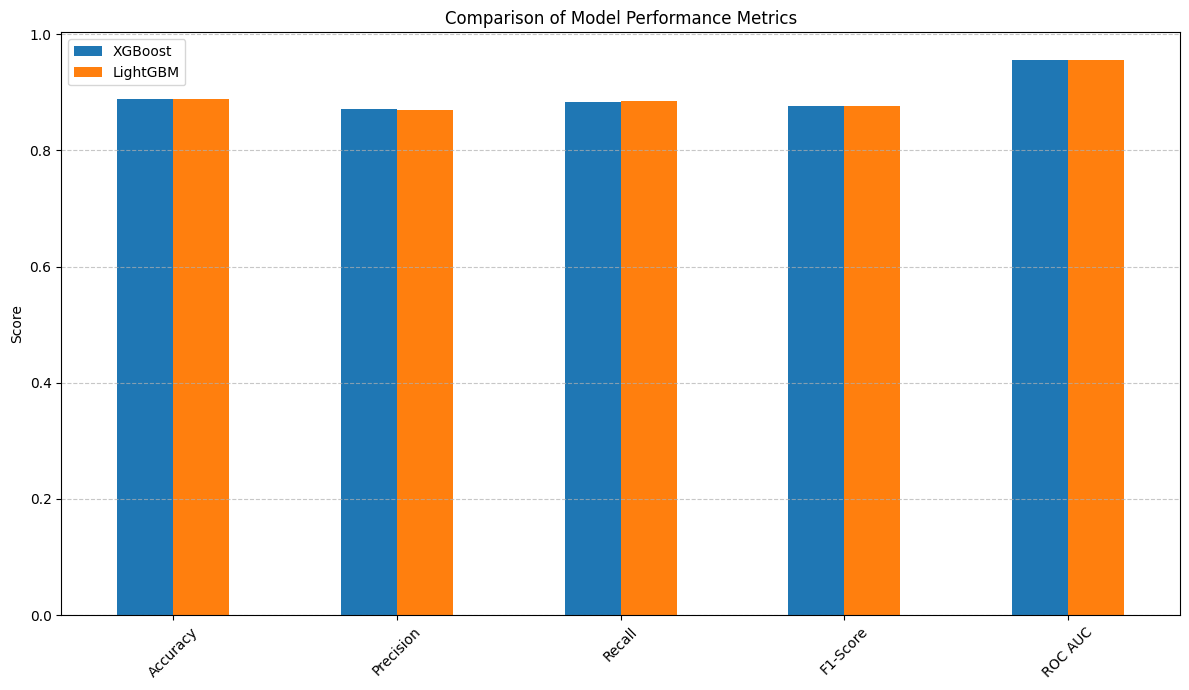

In [39]:
metrics_df.plot(kind='bar', figsize=(12, 7))
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### ROC Curve Comparison

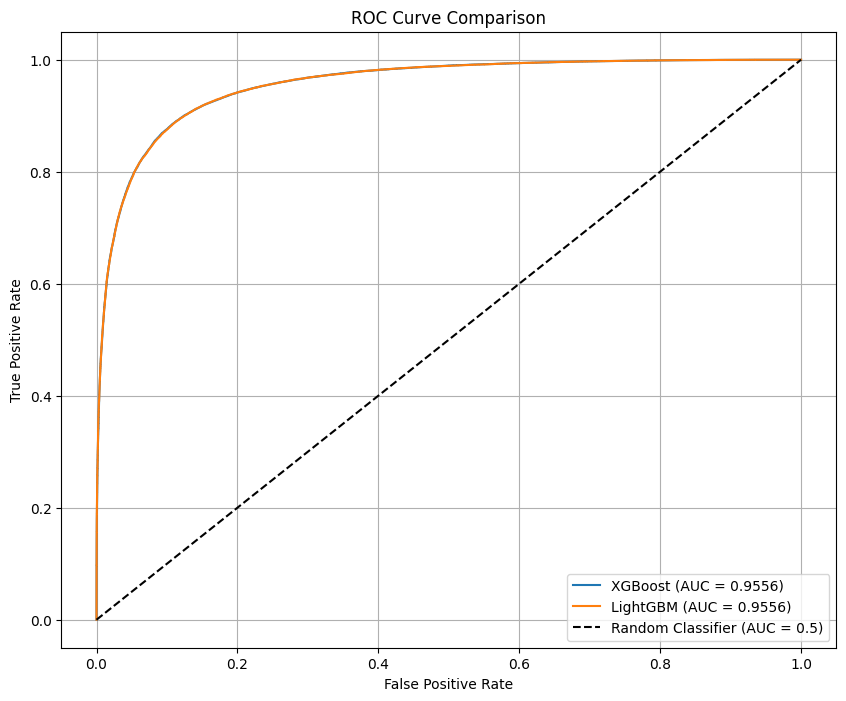

In [40]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 8))

# XGBoost ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_proba)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {xgb_metrics["ROC AUC"]:.4f})')

# LightGBM ROC Curve
fpr_lgbm, tpr_lgbm, _ = roc_curve(y_test, y_test_proba_lgbm)
plt.plot(fpr_lgbm, tpr_lgbm, label=f'LightGBM (AUC = {lgbm_metrics["ROC AUC"]:.4f})')

# Plotting the random classifier (diagonal line)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.5)')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.grid(True)
plt.show()


### Making Predictions on `test.csv` and Creating Submission File

In [41]:
# Load the test dataset
df_test = pd.read_csv('test.csv')

# Display the first few rows of the test set
display(df_test.head())


,id,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
0,630000,58,1,3,120,288,0,2,145,1,0.8,2,3,3
1,630001,55,0,2,120,209,0,0,172,0,0.0,1,0,3
2,630002,54,1,4,120,268,0,0,150,1,0.0,2,3,7
3,630003,44,0,3,112,177,0,0,168,0,0.9,1,0,3
4,630004,43,1,1,138,267,0,0,163,0,1.8,2,0,7


In [43]:
# Store 'id' for submission file
test_ids = df_test['id']

# Drop the 'id' column from the test features
X_test_submission = df_test.drop('id', axis=1)

# Make predictions using the trained XGBoost model, getting probabilities for the positive class (1 = Presence)
final_probabilities = xgb_model.predict_proba(X_test_submission)[:, 1]

# Create a submission DataFrame
submission_df = pd.DataFrame({'id': test_ids, 'Heart Disease': final_probabilities})

# Display the first few rows of the submission file
display(submission_df.head())

# Save the submission file
submission_df.to_csv('submission.csv', index=False)

print("Submission file 'submission.csv' created successfully with probabilities.")

,id,Heart Disease
0,630000,0.975841
1,630001,0.012806
2,630002,0.990595
3,630003,0.009396
4,630004,0.222716


Submission file 'submission.csv' created successfully with probabilities.
